# Tæthedsbaseret klyngedannelse af elnet-målestationer med PROC MODECLUS

## Resumé

Et el-forsyningsselskab bruger PROC MODECLUS til at finde
nonparametriske, tæthedsbaserede klynger blandt sine
elnet-målestationer (transformerstationer og feedersensorer) alene ud
fra deres kortkoordinater. MODECLUS estimerer en tæthedsflade over
målestationerne og behandler klynger som højtæthedsområder adskilt af
lavtæthedskløfter. Kørslen på 90 simulerede stationer med en
uniform-kernel-radius på 3 km genfinder de tre tætte servicelommer, vi
har bygget ind i dataene, som de tre største klynger (24, 24 og 21
stationer), mens de spredte landdistrikts-stationer falder i tynde
områder og splitter op i deres egne en- og to-stations-mikroklynger.
Denne mængde af isolerede stationer er selve det operationelle
leverance: en kandidatliste over fjerntliggende aktiver til
kapitalplanlægningsteamet.

## Datakilder

| Datasæt | Rækker | Beskrivelse |
|---------|------|-------------|
| `grid_sites` | 90 | Syntetiske elektriske distributionsmålestationer genereret direkte med `call streaminit(70531)` og `rand()`. Tre tætte servicelommer (Bykerne, Forstad, Industri) trukket fra bivariate normalfordelinger omkring separate kortcentroider, plus 22 spredte landdistrikts-stationer trukket uniformt over territoriet. |

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `site_id` | Num | Unik identifikator for målestation (1-90). |
| `region` | Char | Planlægningsmærkat, der registrerer, hvordan hver station blev genereret (Bykerne, Forstad, Industri, Landdistrikt); holdes ude af klyngedannelsen. |
| `x_km`, `y_km` | Num | Stationens placering i kilometer på forsyningsselskabets planlægningsgitter; klyngedannelsesvariablerne. |
| `peak_load_mw` | Num | Observeret årlig spidsbelastning (MW) på stationen; medtages til senere fortolkning. |

# Tæthedsbaseret klyngedannelse af elnet-målestationer

Et regionalt el-distributionsselskab driver et net af
**målestationer** -- transformerstationer og feedersensorer -- spredt
over sit forsyningsterritorium. Planlæggerne ønsker at gruppere disse
stationer i naturlige **servicelommer** udelukkende baseret på
geografi, uden på forhånd at angive, hvor mange grupper der findes, og
at identificere **isolerede landdistriktsaktiver**, der ikke hører til
nogen tæt lomme.

`PROC MODECLUS` er velegnet til dette: den udfører *nonparametrisk,
tæthedsbaseret* klyngedannelse. Den estimerer en tæthedsfunktion over
stationerne og behandler derefter klynger som områder med høj
stationstæthed adskilt af lavtæthedskløfter. Spredte outliers ender i
deres egne bittesmå klynger i stedet for at blive opslugt af en lomme
-- præcis den adfærd, vi ønsker til at flage fjerntliggende stationer.

Denne notebook:
1. Genererer et realistisk syntetisk stationsnetværk på 90 stationer.
2. Estimerer stationstæthed med en **uniform kernel** og scanner
   udjævningsradiussen `R=` for at bekræfte, at de genfundne lommer er
   stabile.
3. Fastlægger en arbejdsradius, skriver et `OUT=`-datasæt med hver
   stations tæthed og klyngemærkat, og kortlægger resultatet.

## Trin 1 -- Generér et syntetisk netværk af målestationer

Vi simulerer 90 stationer. Tre tætte **servicelommer** trækkes fra
bivariate normalfordelinger omkring separate kortcentroider (Bykerne
nær (12, 30), Forstad nær (30, 15), Industri nær (20, 42)), hvilket
giver kompakte højtæthedsklumper på 24, 24 og 20 stationer. Et fjerde
sæt på 22 **Landdistrikt**-stationer trækkes uniformt over
territoriet, hvilket giver de spredte, tyndt fordelte stationer, som
et forsyningsselskab ville betragte som isolerede.

`region`-mærkatet registrerer, hvordan hver station blev genereret; vi
**holder den bevidst ude** af klyngedannelsen, så MODECLUS genfinder
strukturen alene ud fra koordinaterne. `peak_load_mw` medtages til
senere fortolkning.

In [1]:
data grid_sites;
   CALL streaminit(70531);
   LÆNGDE region $ 12;

   /* Dense urban service pocket */
   GØR site_id = 1 TIL 24;
      region = 'Bykerne';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      UDDATA;
   SLUT;

   /* Suburban pocket */
   GØR site_id = 25 TIL 48;
      region = 'Forstad';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      UDDATA;
   SLUT;

   /* Industrial pocket (higher peak load) */
   GØR site_id = 49 TIL 68;
      region = 'Industri';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      UDDATA;
   SLUT;

   /* Scattered rural sites (sparse, low load) */
   GØR site_id = 69 TIL 90;
      region = 'Landdistrikt';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      UDDATA;
   SLUT;

   MÆRKAT region='Region' x_km='X (km)' y_km='Y (km)' peak_load_mw='Spidsbelastning (MW)';
KØR;

TITEL 'Syntetiske elnet-målestationer';
PROCEDURE GENNEMSNIT data=grid_sites n mean std MIN MAX maxdec=2;
   KLASSE region;
   VARIABEL x_km y_km peak_load_mw;
   MÆRKAT region='Region' x_km='X (km)' y_km='Y (km)' peak_load_mw='Spidsbelastning (MW)';
KØR;

                                             Syntetiske elnet-målestationer                                             

                                                  The MEANS Procedure

                                            Analysis Variable : x_km X (km)

        Region                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        Bykerne                  24          12.07           1.34           8.65          14.42
        Forstad                  24          29.96           1.73          26.51          33.60
        Industri                 20          20.36           0.96          18.52          21.53
        Landdistrikt             22          29.79          10.62          11.06          47.45
        ---------------------------------------------------------------------------------------

                                            Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Syntetiske elnet-målestationer.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Gennemsnittene bekræfter tre tætte lommer og én diffus gruppe. De
tre tætte regioner har små koordinat-standardafvigelser (omkring
1-1,7 km på hver akse) omkring velseparerede centroider, mens
Landdistrikt-gruppen spreder sig over hele gitteret
(standardafvigelser over 10 km på begge akser). Spidsbelastningen
adskiller også lommerne -- Industri-stationer ligger gennemsnitligt på
omkring 6 MW, Bykerne omkring 4,6 MW, Forstad omkring 2,7 MW, og
Landdistrikt-stationer omkring 1,5 MW -- hvilket er nyttig kontekst,
når først de geografiske klynger er fundet.

## Trin 2 -- Uniform-kernel-tæthedsklyngedannelse og en radius-scanning

Uniform-kernel-tæthedsestimering bruger en **radius `R=`**: hver
station inden for `R` kilometer bidrager til en stations lokale
tæthed. Lille `R` giver en bølget tæthed, der fragmenterer
territoriet; stor `R` overudjævner og sammensmelter lommer. En
SAS-ekspert stoler aldrig på en enkelt værdi -- de scanner et
radiusinterval og kigger efter et klyngeantal, der er **stabilt**,
hvor de tætte lommer består, mens kun antallet af spredte enkeltstationer
driver.

Her vælger `M=1` klyngedannelsesmetode 1 (den almindelige
nonparametriske metode), og vi anmoder om radier `R=2.5 til 4 med
skridt 0.5` i ét kald. MODECLUS kører analysen én gang pr. radius og
rapporterer antallet af klynger for hver. `SHORT` undertrykker de
detaljerede statistikker pr. klynge.

In [2]:
TITEL 'Tæthedsklyngedannelse med uniform kernel for elnet-målestationer';
title2 'Radius-scanning R = 2.5 til 4.0 km';

PROCEDURE modeclus data=grid_sites m=1 r=2.5 TIL 4 EFTER 0.5 short;
   VARIABEL x_km y_km;
   id site_id;
   MÆRKAT x_km='X (km)' y_km='Y (km)';
KØR;

                            Tæthedsklyngedannelse med uniform kernel for elnet-målestationer                            
                                           Radius-scanning R = 2.5 til 4.0 km                                           


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Tæthedsklyngedannelse med uniform kernel for elnet-målestationer.
NOTE: Option TITLE2 changed to Radius-scanning R = 2.5 til 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klyngeantallet bevæger sig kun svagt gennem scanningen -- 23 klynger
ved `R=2.5`, 22 ved `R=3.0`, 19 ved `R=3.5`, og 18 ved `R=4.0`. De høje
rå antal kommer fra de spredte landdistrikts-stationer: hver isoleret
station ligger i sit eget tynde nabolag og danner en enkelt-stations-
klynge, så de fleste af de 18-23 "klynger" er enkeltstationer. Det, der
forbliver konstant nedenunder, er den struktur, der betyder noget -- de
tre tætte lommer forbliver tre store, velseparerede klynger ved hver
radius. Efterhånden som `R` udvides, smelter nogle af de spredte
enkeltstationer sammen med en nabo eller en nærliggende lomme, hvilket
er grunden til, at det samlede antal driver langsomt nedad i stedet
for at svinge vildt. Denne stabilitet er signalet om, at
tre-lomme-løsningen er reel og ikke et artefakt af én enkelt
båndbredde.

## Trin 3 -- Endelig klyngeløsning til kortlægning

Efter at have set, at de tre lommer er stabile gennem scanningen,
fastlægger vi en enkelt arbejdsradius (`R=3` km) og anmoder om
**ALL**-tilvalget for den fulde visning pr. klynge, plus **OUT=** for
at skrive de oprindelige koordinater sammen med
`DENSITY`-tæthedsestimatet og `CLUSTER`-klyngetildelingen, så vi kan
kortlægge resultatet. Klynger nummereres efter faldende modetæthed, så
de tætteste lommer er klynge 1, 2 og 3, og de spredte stationer får de
højere numre.

In [3]:
TITEL 'Endelig tæthedsbaseret klyngeløsning';
title2 'Uniform kernel, R = 3 km';

PROCEDURE modeclus data=grid_sites m=1 r=3 out=join_out ALL;
   VARIABEL x_km y_km;
   id site_id;
   MÆRKAT x_km='X (km)' y_km='Y (km)';
KØR;

                                          Endelig tæthedsbaseret klyngeløsning                                          
                                                Uniform kernel, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
  


NOTE: Option TITLE changed to Endelig tæthedsbaseret klyngeløsning.
NOTE: Option TITLE2 changed to Uniform kernel, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klynge-oversigten gør strukturen eksplicit. `R=3`-løsningen
returnerer **22 klynger**, men de er skarpt lagdelt efter tæthed:

- **Klynge 1** -- 24 stationer, modetæthed omkring 0,0090 (Bykerne-lommen).
- **Klynge 2** -- 24 stationer, modetæthed omkring 0,0079 (Forstad-lommen).
- **Klynge 3** -- 21 stationer, modetæthed omkring 0,0079
  (Industri-lommen; den samler én landdistrikt-station op, der lå på
  dens kant).
- **Klynge 4** -- 3 stationer, modetæthed omkring 0,0012 -- en lille
  gruppe, klart tyndere end de tre lommer, men stadig tættere end
  enkeltstationerne.
- **Klynge 5-22** -- atten enkelt-stations-klynger, alle med en
  modetæthed omkring 0,0004, omtrent tyve gange tyndere end lommerne.

De tre tætte lommer tegner sig for 69 af de 90 stationer; de resterende
21 stationer er de spredte landdistriktsaktiver, hver liggende alene
eller næsten alene i et lavtæthedsnabolag. Tæthed, ikke et forudbestemt
klyngeantal, trækker grænsen mellem en servicelomme og en isoleret
station.

## Trin 4 -- Kortlæg klyngerne

Vi mærker hver station efter, om den landede i en af de tre tætte
lommer (`cluster <= 3`) eller i en tynd mikroklynge, og afbilder
derefter hver station ved sine kortkoordinater farvet efter denne
status. Dette er planlæggerens synsvinkel: tætte lommer, der skal
forvaltes som serviceterritorier, og isolerede stationer, der skal
flages til separat behandling.

                                       Genfundne tætte klynger og isolerede anlæg                                       
                                   Tæthedsklyngedannelse med uniform kernel, R = 3 km                                   




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Genfundne tætte klynger og isolerede anlæg.
NOTE: Option TITLE2 changed to Tæthedsklyngedannelse med uniform kernel, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


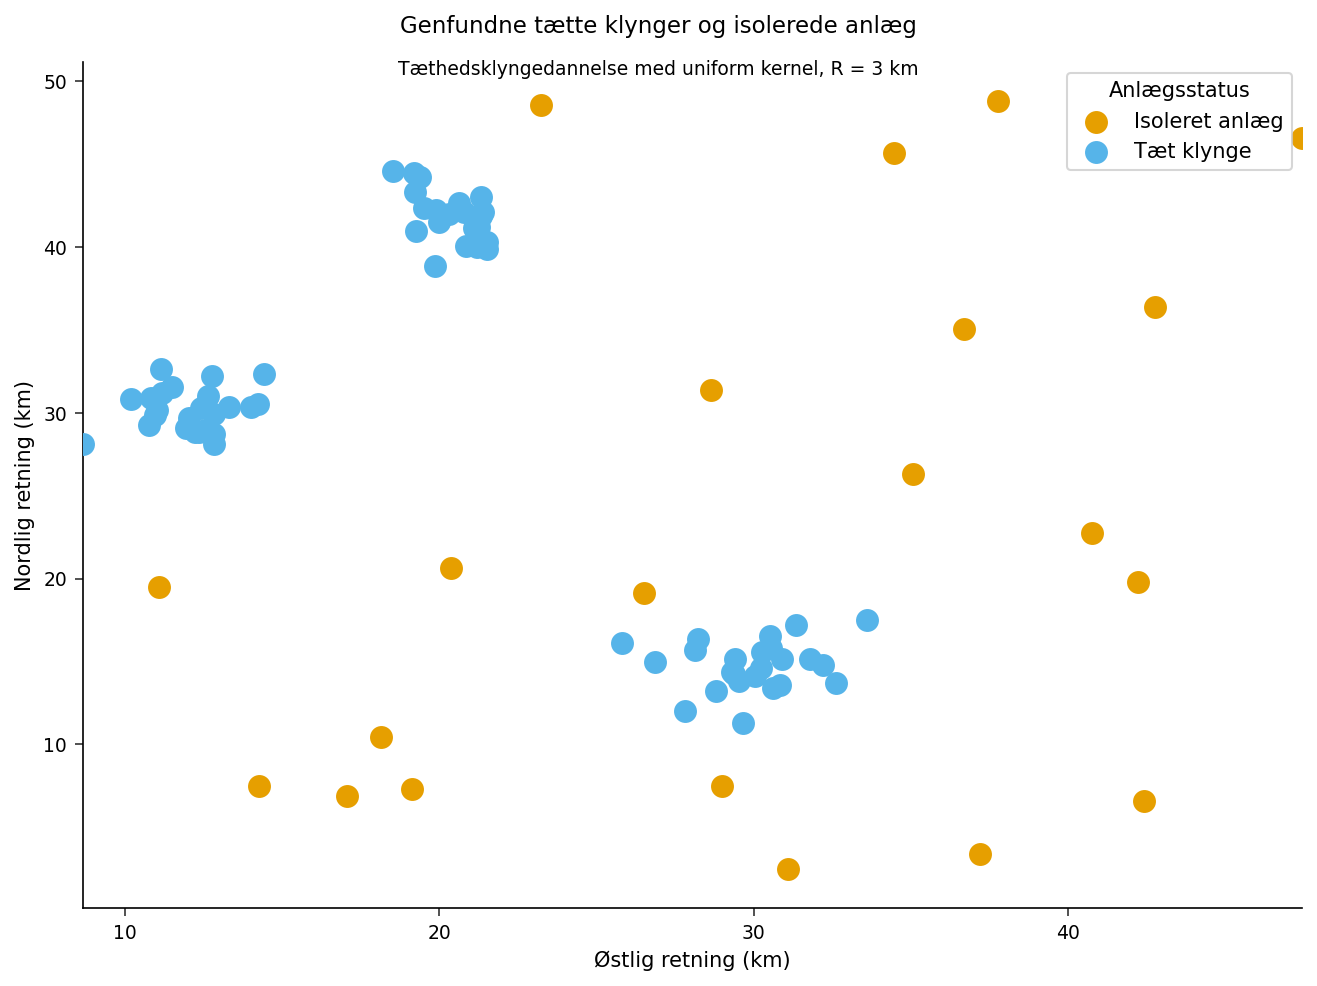

In [4]:
data mapped;
   SÆT join_out;
   LÆNGDE status $ 24;
   HVIS CLUSTER <= 3 SÅ status = 'Tæt klynge';
   ELLERS status = 'Isoleret anlæg';
   MÆRKAT status='Status' x_km='X (km)' y_km='Y (km)' CLUSTER='Klynge';
KØR;

TITEL 'Genfundne tætte klynger og isolerede anlæg';
title2 'Tæthedsklyngedannelse med uniform kernel, R = 3 km';
PROCEDURE SGPLOT data=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS MÆRKAT='Østlig retning (km)';
   YAXIS MÆRKAT='Nordlig retning (km)';
   keylegend / TITEL='Anlægsstatus';
KØR;

TITEL;

## Fortolkning af resultaterne

**Hvad MODECLUS fandt.** Drevet udelukkende af `(x_km, y_km)`
genfinder proceduren de tre tætte servicelommer, vi har bygget ind i
dataene -- Bykerne-, Forstad- og Industri-klumperne -- som de tre
største, tætteste klynger (24, 24 og 21 stationer). De spredte
landdistrikts-stationer, trukket uniformt over territoriet, falder i
tynde områder og splitter op i deres egne en- og
to-stations-klynger i stedet for at blive opslugt af en lomme. På
kortet er de punkterne adskilt fra de tre tætte klumper. Denne isolerede
mængde er selve den operationelle leverance: en kandidatliste over
fjerntliggende aktiver til kapitalplanlægningsteamet.

**Hvorfor udjævningsscanningen betyder noget.** Ingen enkelt `R` er
autoritativ for nonparametrisk tæthedsklyngedannelse. At scanne
`R=2.5 til 4 med skridt 0.5` lader os bekræfte, at lommerne er
*stabile* på tværs af udjævningsniveauer i stedet for et artefakt af
én båndbredde. Gennem scanningen bevæger klyngeantallet sig kun fra 23
ned til 18, og ændringen ligger udelukkende i antallet af spredte
enkeltstationer -- de tre tætte lommer består gennem det hele. Hvor
strukturen holdt stabil på denne måde, har vi en forsvarlig løsning;
hvis antallet havde svinget vildt, ville strukturen have været skrøbelig
og burde ikke drive investeringsbeslutninger.

**Tæthed lagdeler resultatet.** Fordi klynger nummereres efter faldende
modetæthed, er opdelingen mellem lommer og isolerede stationer
kvantitativ, ikke vilkårlig: de tre lommer ligger nær modetæthed
0,008-0,009, mens hver isoleret station ligger nær 0,0004, omtrent
tyve gange tyndere. En planlægger kan sætte en tæthedsgrænse og aflæse
de isolerede aktiver direkte fra `CLUSTER`- og `DENSITY`-kolonnerne i
`join_out`.

**Praktisk anvendelse.** `join_out`-datasættet giver hver station en
tæthed og en klyngemærkat, der kan så efterfølgende arbejde --
dimensionering af mandskab og reservedele pr. servicelomme, ruteplanlægning
af inspektionskredsløb, eller prioritering af nethærdning i den tætte
industriklynge (højeste `peak_load_mw`, omkring 6 MW) -- mens de
isolerede landdistriktsstationer planlægges til separat,
lavere-frekvent vedligeholdelse.

*Bemærkning om syntetiske data:* koordinater og belastninger simuleres
med en fast startværdi (`call streaminit(70531)`), så notebooken er
fuldt reproducerbar offline; på reelle forsyningsdata ville man
erstatte opmålte stationskoordinater og målte spidsbelastninger. De
nøjagtige klyngeantal afhænger af det tilfældige udtræk og af den
valgte radius.